In [10]:
import numpy as np
import pandas as pd
#import umap
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq

#from muon import prot as pt
from sklearn import preprocessing
import os
import itertools
import sys
path0 = '../../'
sys.path.append(path0+'phenotyping/')
from collections import defaultdict
from tqdm import tqdm
import seaborn as sns
import pickle
input_dir = 'pre_processed_files/'
output_fig = '../figures'
def strip_extension(self):
    '''strip the file extension from a pd.Series of file names'''
    return self.apply(lambda x: os.path.splitext(x)[0])

from phenotyping_utils import generate_anndata_from_ark_analysis
# Add the method to the Pandas Series class
pd.Series.strip_extension = strip_extension
%matplotlib inline

In [8]:
cell_table_path=path0+'../segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv'
biosamples_path=path0+'../IMC_data/ExtraDocs/processed_response.csv'
adata = generate_anndata_from_ark_analysis(cell_table_path=cell_table_path,biosamples_path=biosamples_path)
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].copy()
resection = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)'] == 'RESECTION']

/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [362]:
core[core.obs.Pixie == 'Vim+ Cancer / NK'].obs.acquisition_ID.nunique()

178

In [241]:
#neigh_all is a dictionary, containing the fov as key, and a dataframe of z-scores.The dataframe contains only the element in the fov
with open('neighbours_matrix.pkl', 'rb') as f:
    data = pickle.load(f)


Take only the core

In [423]:
labels_list = adata.obs.Pixie.unique()#these are all the cell types
labels_list2 = (core.obs.Pixie.value_counts()/core.obs.acquisition_ID.nunique()>20)#Filter out cell types that have few cells
labels_list2 = labels_list2[labels_list2].index.to_list()
def expand_df(tb,labels_list,labels_list2):
    '''
    Takes the dataframe tb, creates a dataframe full of zeros where it embeds tb into. The extracts only the columns and rows with labels in label_list2
    '''
    temp_matrix = pd.DataFrame(0,index = labels_list,columns=labels_list)
    sub_list = tb.index#label list
    #tb.replace([np.inf, -np.inf], np.nan, inplace=True) # convert inf to nan, next line everything is replaced with 0
    temp_matrix.loc[sub_list,sub_list]=tb
    temp_matrix = temp_matrix.loc[labels_list2,labels_list2]
    temp_values = temp_matrix.values
    return temp_values

X_enrichment = []
X_contact = []
y = []
core_ids = set(core.obs.acquisition_ID)
for id,sub_dic in data.items():
    if id not in core_ids:
        continue
    tb_en = sub_dic['enrichment']
    tb_cont = sub_dic['interaction']
    X_enrichment +=[expand_df(tb_en,labels_list,labels_list2)]
    X_contact +=[expand_df(tb_cont,labels_list,labels_list2)]
    y+=[id]
y = np.vectorize(dict(core.obs[['acquisition_ID','Response']].values).get)(y)
X_enrichment = np.array(X_enrichment)
X_contact = np.array(X_contact)

/tmp/ipykernel_78409/2631714736.py:6: RuntimeWarning: invalid value encountered in divide
  mean_nR = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list2,columns=labels_list2)#.fillna(-cutoff)
/tmp/ipykernel_78409/2631714736.py:10: RuntimeWarning: invalid value encountered in divide
  mean_pCr = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list2,columns=labels_list2)#.fillna(-cutoff)


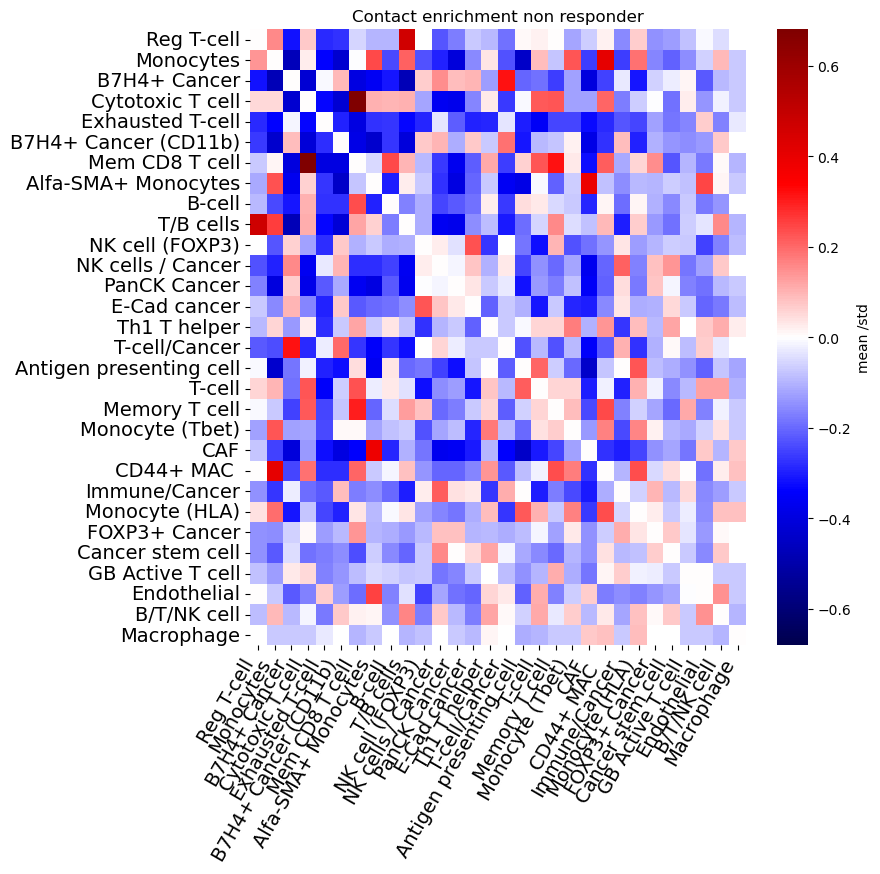

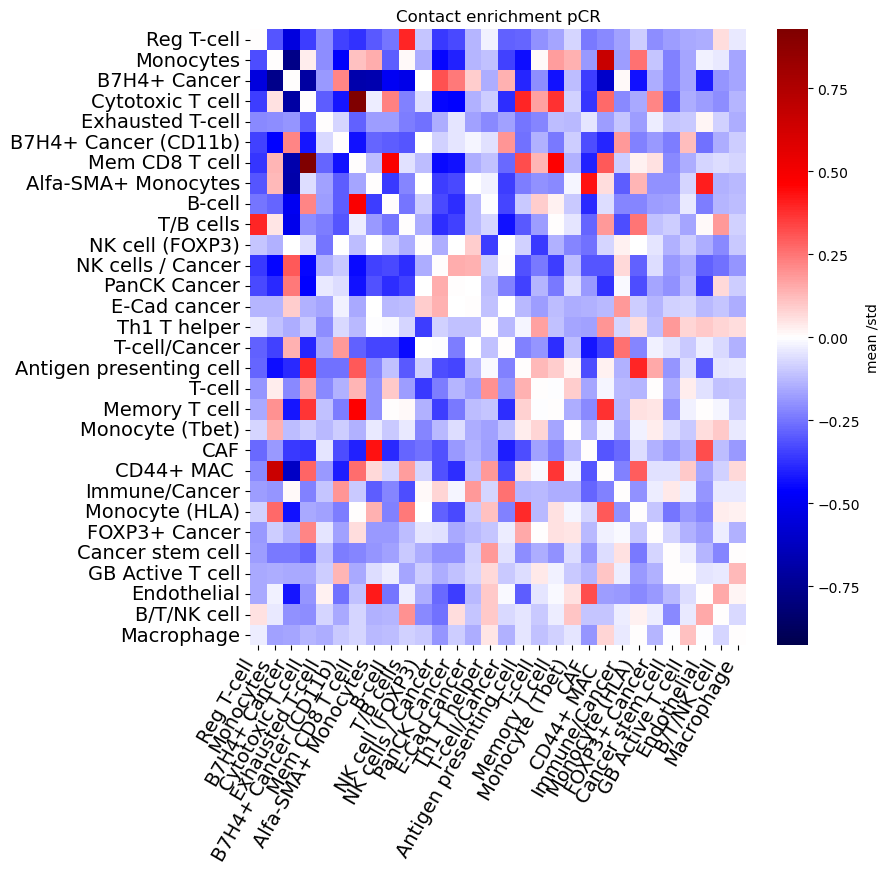

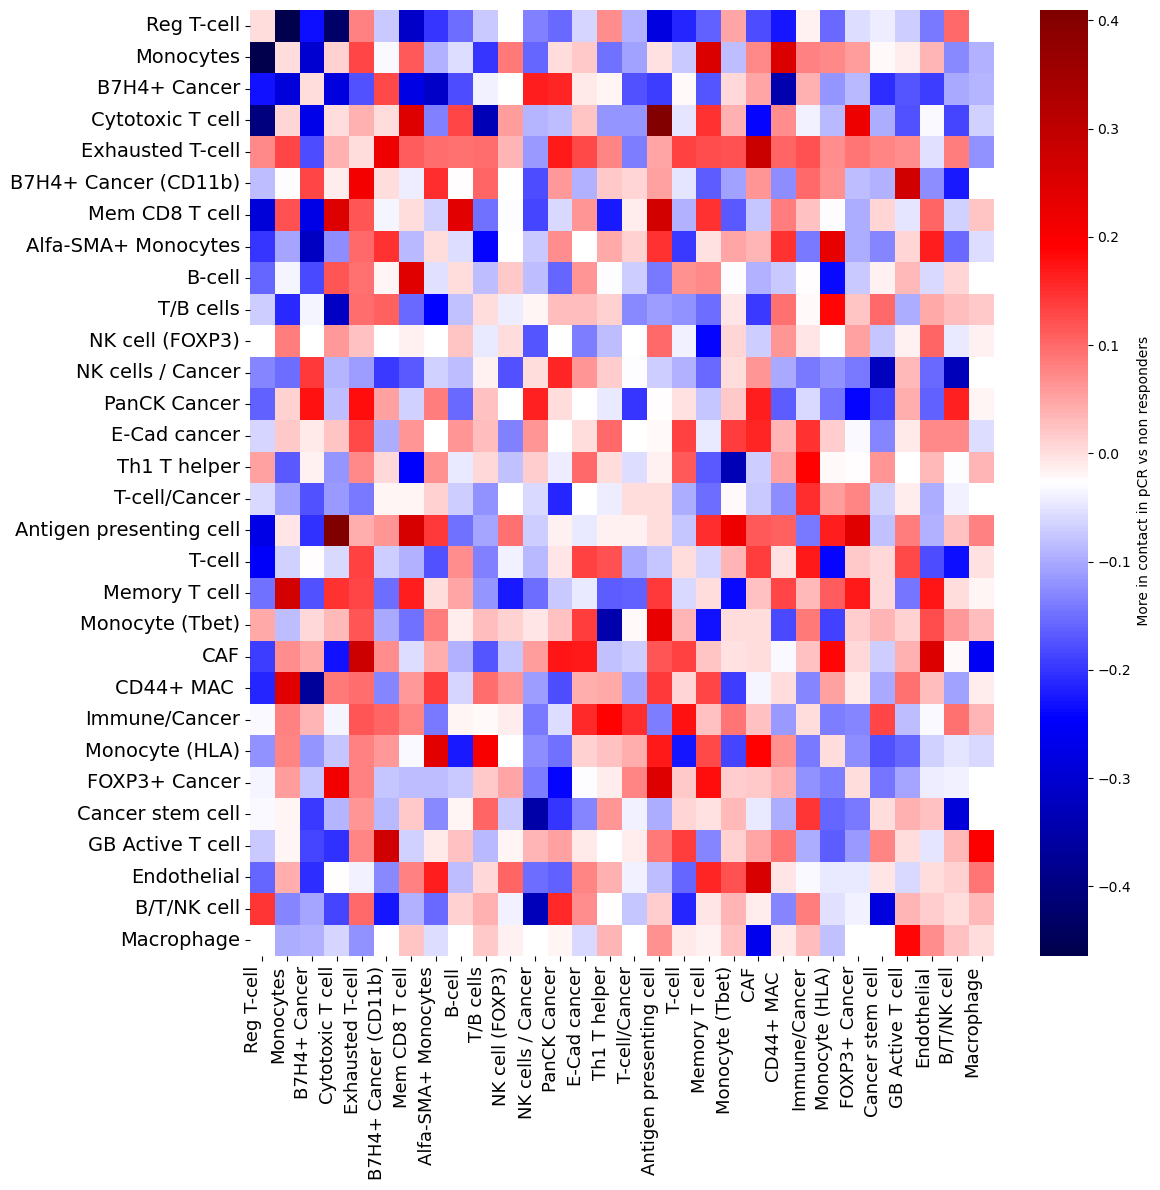

In [424]:
cutoff = 2
#axs[2].sharey(axs[1])
#axs[0].get_shared_y_axes().join(axs[1],axs[2])
def heatmap_mean_response(X,y,description):
    aux = X[y == 'Non-Responder']
    mean_nR = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list2,columns=labels_list2)#.fillna(-cutoff)
    
    np.fill_diagonal(mean_nR.values,0)
    aux = X[y == 'pCR']
    mean_pCr = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list2,columns=labels_list2)#.fillna(-cutoff)
    np.fill_diagonal(mean_pCr.values,0)
    plt.figure(figsize = (8,8))
    plt.title(description+' non responder')
    if description.find('enrichment')>0:
        vmax = np.nanmax(mean_nR.abs().to_numpy())
        vmin = -vmax
        cmap='seismic'
    else:
        vmax = np.nanmax(mean_nR.to_numpy())
        vmin = np.nanmin(mean_nR.to_numpy())
        cmap=None
    sns.heatmap(mean_nR,cmap = cmap,xticklabels=True,yticklabels=True,vmin = vmin,vmax = vmax,cbar = True,cbar_kws={'label':'mean /std'})
    _ = plt.xticks(rotation=60,fontsize = 14,ha='right')
    _ = plt.yticks(fontsize = 14)
    plt.figure(figsize = (8,8))
    plt.title(description+' pCR')
    if description.find('enrichment')>0:
        vmax = np.nanmax(mean_pCr.abs().to_numpy())
        vmin = -vmax
    else:
        vmax = np.nanmax(mean_pCr.to_numpy())
        vmin = np.nanmin(mean_pCr.to_numpy())

    sns.heatmap(mean_pCr,cmap=cmap,xticklabels=True,yticklabels=True,cbar =True,vmin = vmin,vmax = vmax,cbar_kws={'label':'mean /std'})
    _ = plt.xticks(rotation=60,fontsize = 14,ha='right')
    _ = plt.yticks(fontsize = 14)
    plt.figure(figsize = (12,12))
    
    sns.heatmap(mean_pCr-mean_nR,cmap='seismic',xticklabels=True,yticklabels=True,cbar = True,cbar_kws={'label':' More in contact in pCR vs non responders'})
    _ = plt.xticks(fontsize = 13,ha='right')
    _ = plt.yticks(fontsize = 14)
    plt.tight_layout()
    return mean_nR,mean_pCr 
mean_nR,mean_pCr  = heatmap_mean_response(X_enrichment,y,'Contact enrichment')
#plt.savefig('../figures/spatial/neigh_diff_response.png')

-1

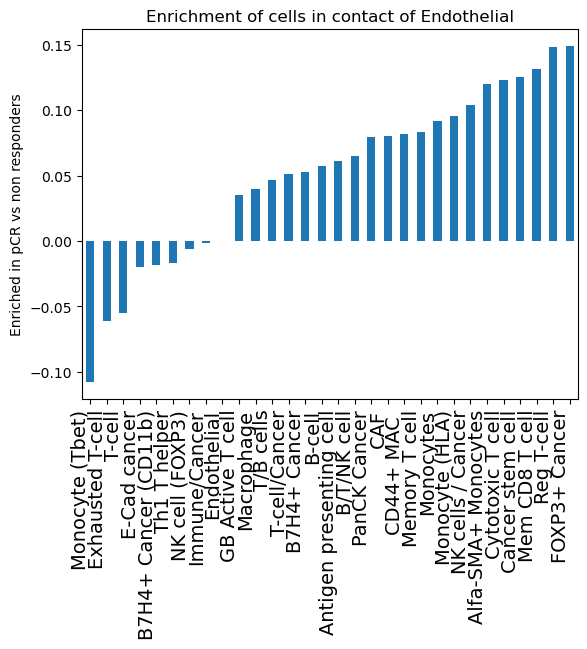

In [367]:
key0 = 'Endothelial'
plt.title('Enrichment of cells in contact of '+key0)
(mean_pCr-mean_nR)[key0].sort_values().plot(kind = 'bar')
_ = plt.xticks(rotation=90,fontsize = 14,ha='right')
plt.ylabel('Enriched in pCR vs non responders')
'Contact enrichment'.find('enrichmens')

/tmp/ipykernel_78409/2631714736.py:6: RuntimeWarning: invalid value encountered in divide
  mean_nR = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list2,columns=labels_list2)#.fillna(-cutoff)
/tmp/ipykernel_78409/2631714736.py:10: RuntimeWarning: invalid value encountered in divide
  mean_pCr = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list2,columns=labels_list2)#.fillna(-cutoff)


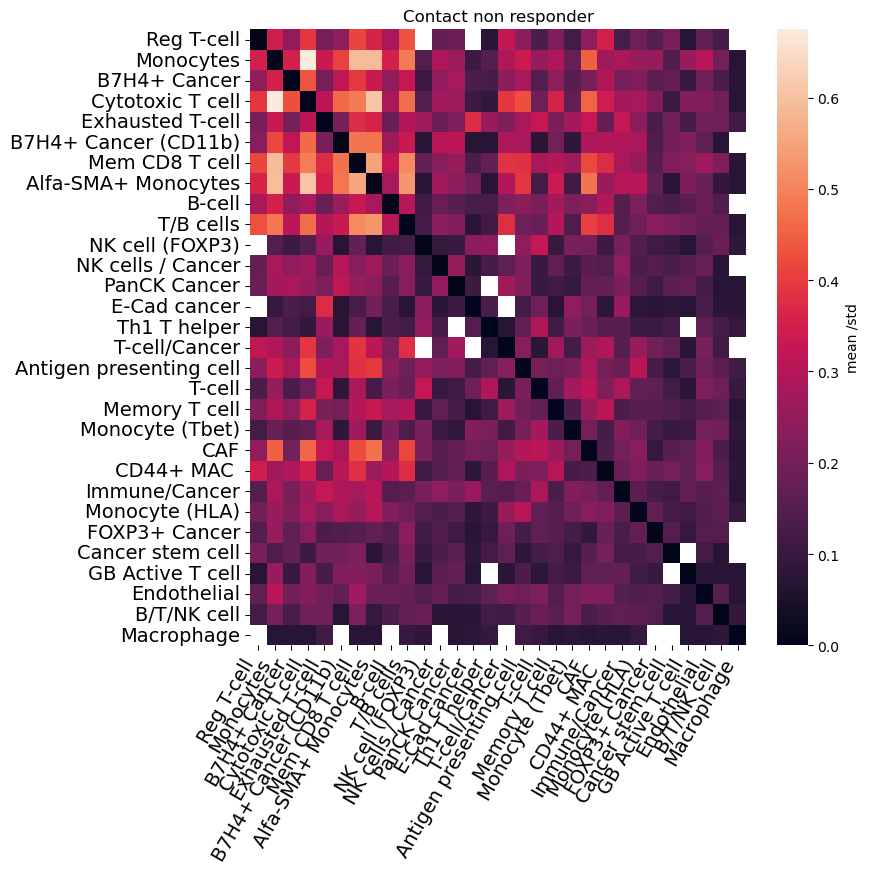

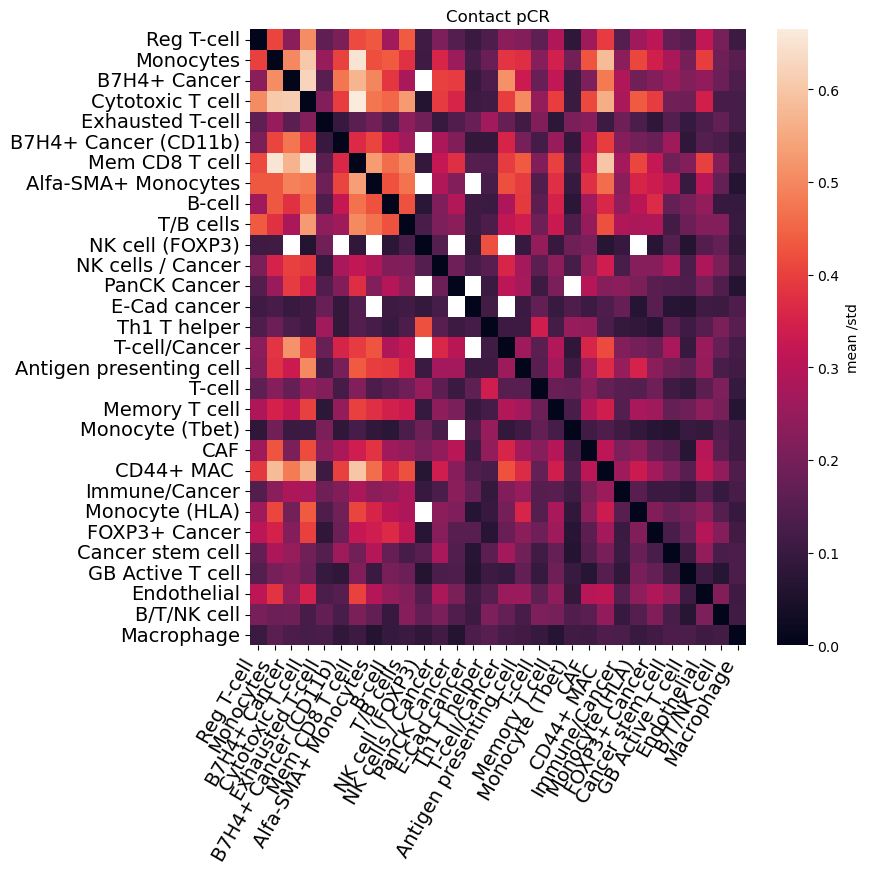

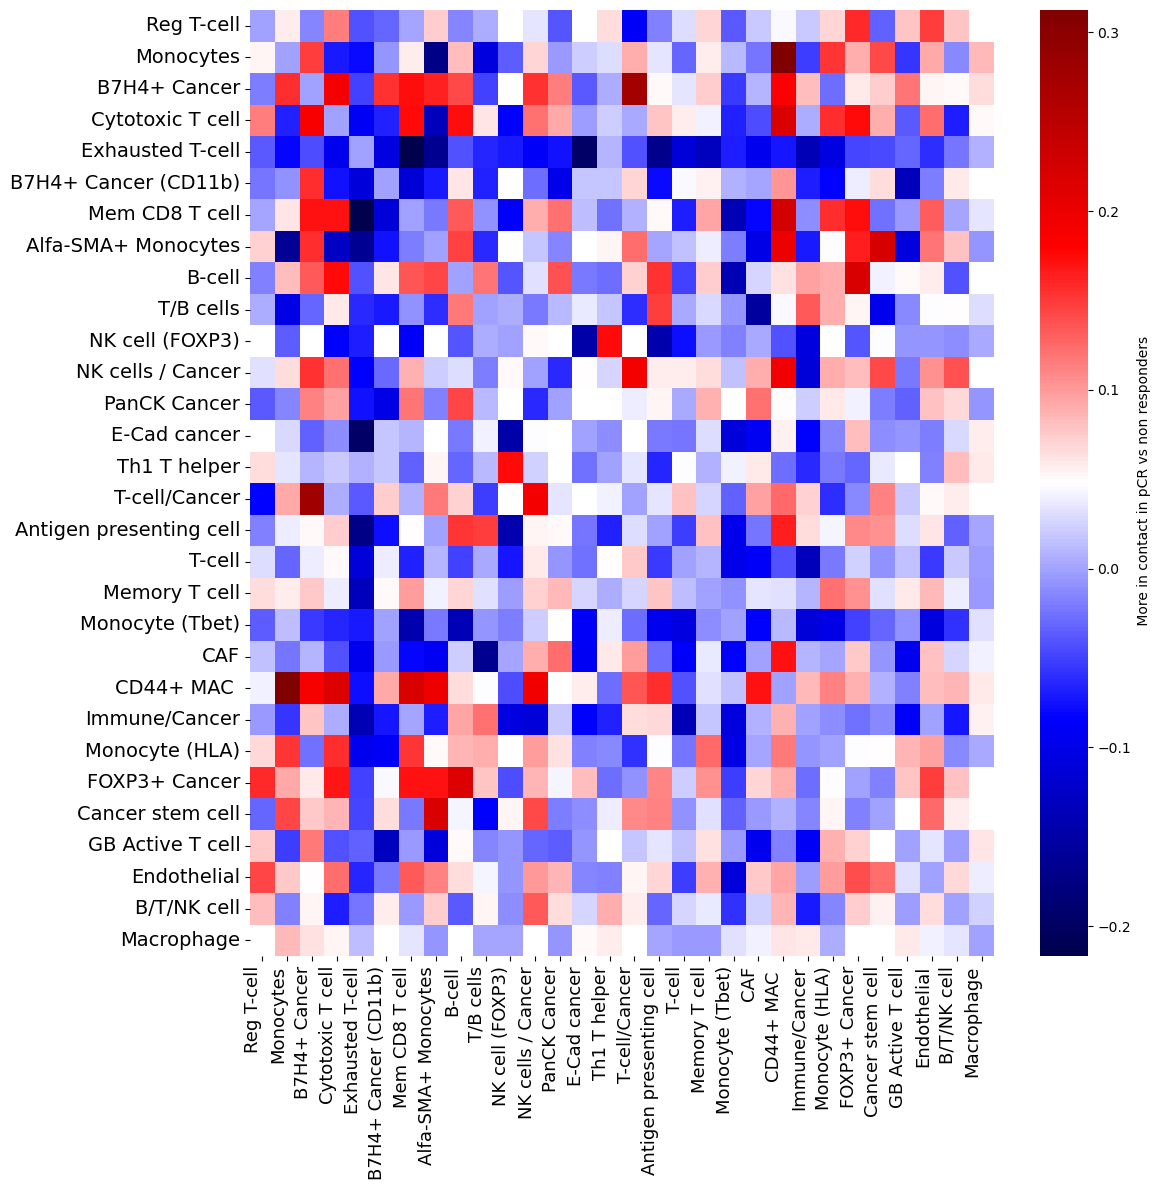

In [425]:
mean_nR,mean_pCr  = heatmap_mean_response(X_contact,y,'Contact')


We now train a calissifier that, for each fov, it computes the contanct matrix enrichment, and uses it to predict response.The features that have more weight in the decision are postulated to have a biological importance

In [375]:
from sklearnex import patch_sklearn
from sklearn.linear_model import LogisticRegression
#from cuml.linear_model import LogisticRegression cuml does not work for multiclass regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV,cross_val_score

In [378]:
max_abs_scaler = preprocessing.MaxAbsScaler()
scaler = preprocessing.StandardScaler(with_mean = False)
le = LabelEncoder()
pca = PCA(n_components=20)
y_num = le.fit_transform(y)

clip_value = 3
X_num = np.array([((x+x.T)/2)[np.triu_indices(len(x),k = 1)] for x in X_contact])
X_num[np.isnan(X_num)] = 0# I don't know why there are nan, as this contains off diagonal terms.

X_num = scaler.fit_transform(X_num)
X_num = np.clip(X_num,-clip_value,clip_value)
#X_num = pca.fit_transform(X_num)
X_train, X_test, y_train, y_test = train_test_split(X_num, y_num, test_size=0.33, random_state=42)
#X_test = np.clip(X_test,-clip_value,clip_value)#scaler.fit_transform(X_test)
#X_train = np.clip(X_train,-clip_value,clip_value)#scaler.fit_transform(X_train)

le.inverse_transform([0,1])

array(['Non-Responder', 'pCR'], dtype='<U13')

In [397]:
C_s_2_inspect = list(map(lambda x:x[0]*x[1], itertools.product([1e-4,1e-3,1e-2,1e-1,1,10],[1,5])))
tuned_parameters = [
    { 'class_weight':['balanced'],"C": C_s_2_inspect},
]

grid_search = GridSearchCV(
    LogisticRegression(), tuned_parameters,scoring='accuracy'
)
grid_search.fit(X_num, y_num)
clf = grid_search.best_estimator_

<Axes: >

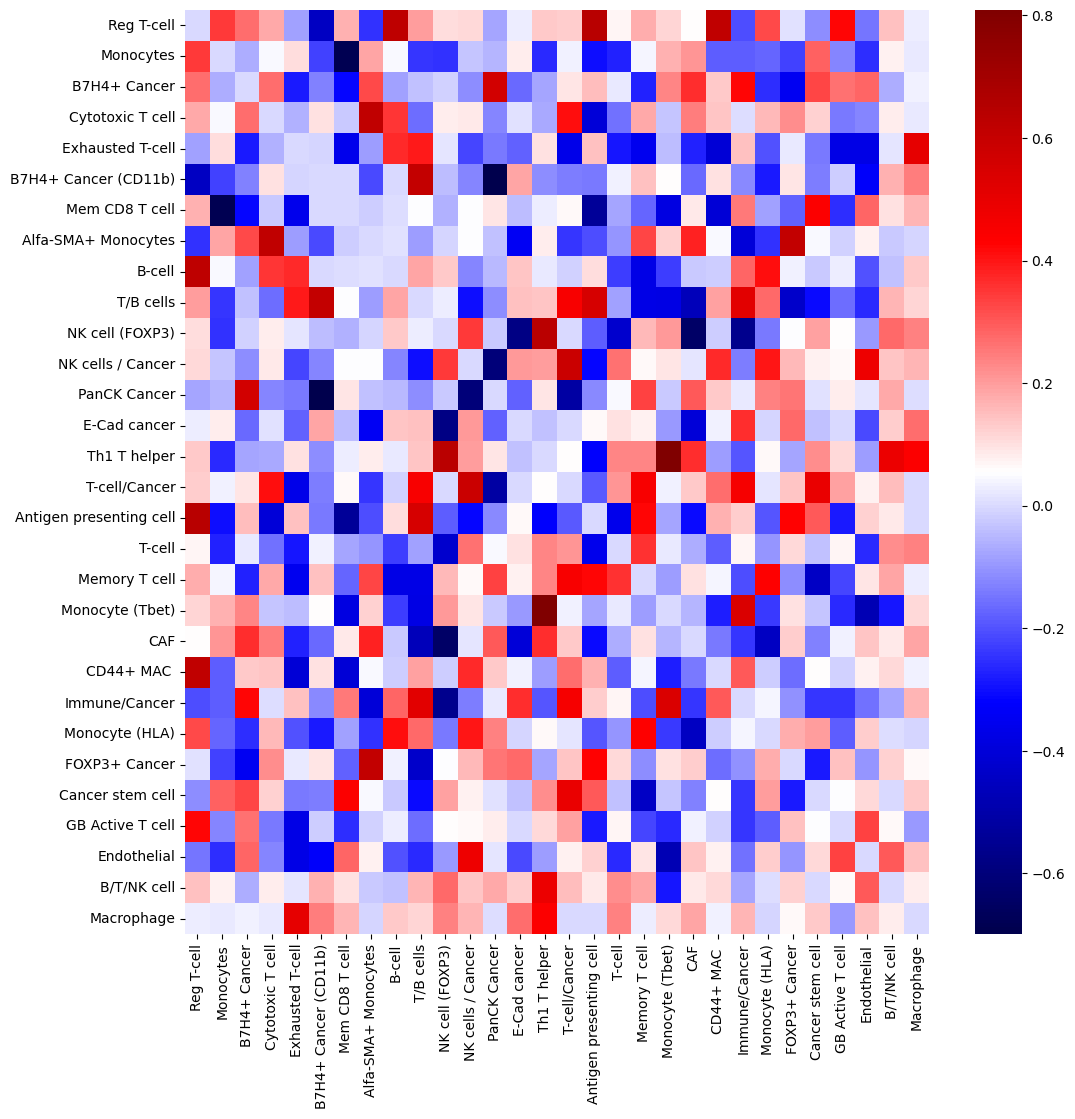

In [395]:
weight_importance  = np.zeros((len(labels_list2),len(labels_list2)))
weight_importance[np.triu_indices(len(labels_list2),k = 1)] = np.squeeze(clf.coef_)#fill the values of upper triangular
weight_importance[np.triu_indices(len(labels_list2),k = 1)[::-1]] = np.squeeze(clf.coef_)#fill the values of the lower triangular
weight_importance = pd.DataFrame(weight_importance,columns=labels_list2,index=labels_list2)
plt.figure(figsize = (12,12))
sns.heatmap(weight_importance,cmap='seismic')

In [396]:
top_features = np.squeeze(np.argsort(np.abs(clf.coef_)))[::-1]#features sorted by their importance in logistic regression 

a = list(zip(*labels_list[np.array(np.triu_indices(len(labels_list),k = 1))[:,top_features]],np.squeeze(clf.coef_)[top_features]))
interpret_lr = pd.DataFrame(a,columns = ['from','top','weight']).iloc[:10]
#positive weights means that it help response
interpret_lr['prediction_towards'] = interpret_lr.weight.apply(lambda x:'pCR' if x>0 else 'Non responder')
#interpret_lr.to_latex()
interpret_lr

,from,top,weight,prediction_towards
0,Monocyte (HLA),Reg T-cell,0.808725,pCR
1,Monocyte (Tbet),Macrophage,-0.698809,Non responder
2,Immune/Cancer,Monocyte (Tbet),-0.685989,Non responder
3,B7H4+ Cancer (CD11b),T-cell/Cancer,-0.643078,Non responder
4,Exhausted T-cell,B7H4+ Cancer,0.642860,pCR
5,B7H4+ Cancer (CD11b),FOXP3+ Cancer,0.632086,pCR
6,Exhausted T-cell,T-cell,0.620664,pCR
7,Exhausted T-cell,Reg T-cell,0.619304,pCR
8,CAF,NK cell (FOXP3),0.618740,pCR
9,Macrophage,Vim+ Cancer / NK,0.613668,pCR


/tmp/ipykernel_78409/631760262.py:61: RuntimeWarning: invalid value encountered in divide
  mean_all = pd.DataFrame(np.nanmean(X_contact,axis = 0)/np.nanstd(X_contact,axis  = 0),index = labels_list2,columns=labels_list2)


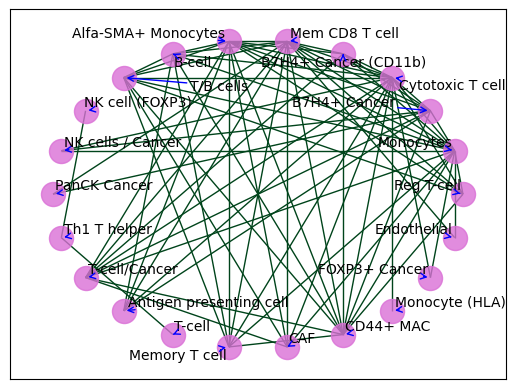

In [470]:
from adjustText import adjust_text
import networkx as nx


def create_corr_network(enrichment,graphical = False):
    G = nx.from_numpy_array(enrichment.values)
    G = nx.relabel_nodes(G,lambda x: list(enrichment.columns)[x])
    ...
    source, to, weight = zip(*G.edges(data = True))
    weight = np.array([w['weight']for w in weight])
    #cond = np.abs(weight)>min_correlation
    source, to, weight = np.stack((source, to, weight),axis = 1).T
    H = nx.Graph()
    

    H.add_weighted_edges_from(np.stack((source, to, weight),axis = 1),data = True)
    return H
def draw_network(G,node,min_weight,positions = None):
    G.remove_edges_from(nx.selfloop_edges(G))
    #G = nx.ego_graph(G,n = node,radius = 2)
    edgelist = np.array(list(G.edges()))
    source, to, weight = zip(*G.edges(data = True))
    weight = np.array([w['weight']for w in weight]).astype(float)
    cond = np.abs(weight)>min_weight
    G.remove_edges_from(edgelist[~cond])
    G.remove_nodes_from(list(nx.isolates(G)))
    edgelist = edgelist[cond]
    weight = weight[cond]
    #positions
    if positions is None:
        positions=nx.circular_layout(G)
    weight_colours = tuple([(1+abs(x))**2 for x in weight])
    nx.draw_networkx_nodes(G,pos = positions,node_color='#DA70D6',nodelist=G.nodes(),
                           #####the node size will be now based on its degree
                           alpha=0.8)
    
    cond = weight>0
    width = 1
    
    nx.draw_networkx_edges(G,edgelist= edgelist[cond],nodelist=G.nodes(),pos = positions,style='solid',
                          ###adds width=weights and edge_color = weights 
                          ###so that edges are based on the weight parameter 
                          ###edge_cmap is for the color scale based on the weight
                          ### edge_vmin and edge_vmax assign the min and max weights for the width
                          width= width, edge_color = np.array(weight_colours)[cond],edge_cmap  = plt.cm.Greens, 
                          edge_vmin = min(weight), edge_vmax=max(weight))
    cond = weight<0
    nx.draw_networkx_edges(G,edgelist= edgelist[cond],nodelist=G.nodes(),pos = positions,style='solid',
                          ###adds width=weights and edge_color = weights 
                          ###so that edges are based on the weight parameter 
                          ###edge_cmap is for the color scale based on the weight
                          ### edge_vmin and edge_vmax assign the min and max weights for the width
                          width=width, edge_color = np.array(weight_colours)[cond],edge_cmap  = plt.cm.Oranges, 
                          edge_vmin = min(weight), edge_vmax=max(weight))
    #Styling for labels
    #nx.draw_networkx_labels(H, positions, font_size=8, 
    #                            font_family='sans-serif')
    b = [plt.annotate(text,positions[text]*1,fontsize = 10) for text in list(G.nodes)]
    adjust_text(b, arrowprops=dict(arrowstyle='->', color='blue'))
    return positions
mean_all = pd.DataFrame(np.nanmean(X_contact,axis = 0)/np.nanstd(X_contact,axis  = 0),index = labels_list2,columns=labels_list2)
np.fill_diagonal(mean_all.values,0)

H = create_corr_network(mean_all,graphical = True)
positions = draw_network(H,node = 'B7H4+ Cancer', min_weight = .3)

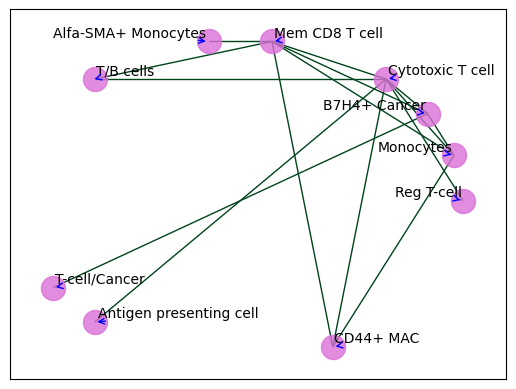

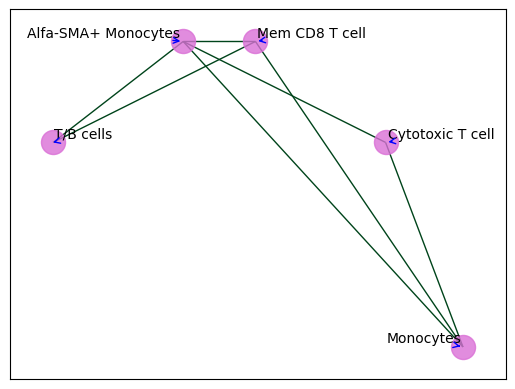

In [472]:
#responder
H = create_corr_network(mean_pCr,graphical = True)
draw_network(H,node = 'B7H4+ Cancer',positions=positions, min_weight = .5)
plt.figure()
#non responders
H = create_corr_network(mean_nR, graphical = True)
_ = draw_network(H,node = 'B7H4+ Cancer',positions=positions, min_weight = .5)

In [447]:
H.remove_edges_from?

Signature: H.remove_edges_from(ebunch)
Docstring:
Remove all edges specified in ebunch.

Parameters
----------
ebunch: list or container of edge tuples
    Each edge given in the list or container will be removed
    from the graph. The edges can be:

        - 2-tuples (u, v) edge between u and v.
        - 3-tuples (u, v, k) where k is ignored.

See Also
--------
remove_edge : remove a single edge

Notes
-----
Will fail silently if an edge in ebunch is not in the graph.

Examples
--------
>>> G = nx.path_graph(4)  # or DiGraph, MultiGraph, MultiDiGraph, etc
>>> ebunch = [(1, 2), (2, 3)]
>>> G.remove_edges_from(ebunch)
File:      ~/anaconda3/lib/python3.9/site-packages/networkx/classes/graph.py
Type:      method